In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width",None)

In [2]:
def find_true_probabilities_equal(odds):
    probabilities = [1/o for o in odds]
    total_probability = sum(probabilities)
    overround = total_probability - 1
    adjustment_factor = overround / len(odds)
    adjusted_probabilities = [(1/o) - adjustment_factor for o in odds]
    return np.array(adjusted_probabilities)


In [3]:
season_list = ['1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']

league_list = ['E0', 'E1', 'E2', 'E3', 'SC0', 'SC1', 'SC2', 'D1', 'D2', 'I1', 'I2', 'SP1', 'SP2', 'F1', 'F2', 'N1', 'B1', 'P1', 'T1', 'G1']  

df_list = []
for league in league_list:
    for season in season_list:
        data_url = f'https://www.football-data.co.uk/mmz4281/{season}/{league}.csv'
        try:
            df = pd.read_csv(data_url)
        except:
            df = pd.read_csv(data_url, encoding='latin')
        df_list.append(df)

main_df = pd.concat(df_list)

main_df['Date'] = pd.to_datetime(main_df['Date'], format='mixed')

main_df = main_df.sort_values(by='Date')

bookmakers = ['B365', 'BW', 'IW', 'PS', 'WH', 'VC']

home_cols = []
draw_cols = []
away_cols = []

for book in bookmakers:
    home_col = book + 'H'
    home_cols.append(home_col)
    draw_col = book + 'D'
    draw_cols.append(draw_col)
    away_col = book + 'A'
    away_cols.append(away_col)

main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
main_df['away_max_odds'] = main_df[away_cols].max(axis=1)

main_df.reset_index(inplace=True)

col_list = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'PSH', 'PSD', 'PSA', 'home_max_odds', 'draw_max_odds', 'away_max_odds']

main_df = main_df[col_list]

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\4122066224.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\4122066224.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\4122066224.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [4]:
main_df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds
0,F2,2016-01-08,Amiens,Reims,1.0,1.0,2.91,2.99,2.88,2.91,3.10,2.88
1,E3,2016-01-10,Wycombe,Exeter,1.0,0.0,2.54,3.47,2.91,2.55,3.60,2.91
2,D1,2016-01-10,Ingolstadt,Hoffenheim,1.0,2.0,2.02,3.64,4.00,2.25,3.64,4.00
3,D1,2016-01-10,Leverkusen,Dortmund,2.0,0.0,3.70,3.84,2.04,3.80,3.84,2.10
4,E1,2016-01-10,Burton,Cardiff,2.0,0.0,2.47,3.33,3.13,2.50,3.40,3.13
...,...,...,...,...,...,...,...,...,...,...,...,...
62713,SC1,2025-12-04,Partick,Hamilton,1.0,2.0,1.83,3.50,4.20,1.83,3.50,4.20
62714,SP2,2025-12-05,Granada,Eibar,0.0,2.0,1.79,3.44,4.89,1.80,3.44,4.89
62715,I1,2025-12-05,Atalanta,Roma,2.0,1.0,2.01,3.56,3.91,2.01,3.60,3.91
62716,I1,2025-12-05,Venezia,Fiorentina,2.0,1.0,3.11,3.28,2.46,3.11,3.28,2.46


In [5]:
main_df = main_df[~main_df['PSH'].isna()]

main_df.reset_index(inplace=True)

In [6]:
main_df[['pinnacle_true_home_prob', 'pinnacle_true_draw_prob', 'pinnacle_true_away_prob']] = main_df.apply(
    lambda row: find_true_probabilities_equal([row['PSH'], row['PSD'], row['PSA']]),
    axis=1,
    result_type='expand'
)

main_df['totes'] = main_df['pinnacle_true_home_prob'] + main_df['pinnacle_true_draw_prob'] + main_df['pinnacle_true_away_prob']

tolerance = 1e-7
mask = np.abs(main_df['totes'] -1 <= tolerance)

assert len(main_df[~mask]) == 0

len(main_df[~mask])

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1290670199.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df[['pinnacle_true_home_prob', 'pinnacle_true_draw_prob', 'pinnacle_true_away_prob']] = main_df.apply(
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1290670199.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df[['pinnacle_true_home_prob', 'pinnacle_true_draw_prob', 'pinnacle_true_away_prob']] = main_df.apply(
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1290670199.py:1: Settin

0

In [7]:
def calculate_ev_from_odds(bookmaker_odds, our_probability):
    payout = bookmaker_odds
    ev = (our_probability * payout) -1
    return ev

In [8]:
def calculate_kelly_stake(bankroll, ev, odds, kelly_fraction=0.25):
    if odds <= 1 or kelly_fraction <= 0:
        return 0.0
    
    stake_fraction = ev / (odds - 1)

    if stake_fraction <= 0:
        return 0.0
    
    stake_fraction *= kelly_fraction

    return stake_fraction * bankroll

In [9]:
main_df['home_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['home_max_odds'],
        row['pinnacle_true_home_prob']
    ),
    axis=1
)

main_df['draw_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['draw_max_odds'],
        row['pinnacle_true_draw_prob']
    ),
    axis=1
)

main_df['away_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['away_max_odds'],
        row['pinnacle_true_away_prob']
    ),
    axis=1
)

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\2786317648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df['home_ev'] = main_df.apply(
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\2786317648.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df['draw_ev'] = main_df.apply(
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\2786317648.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



In [10]:
main_df['max_value'] = main_df[['home_ev', 'draw_ev', 'away_ev']].max(axis=1)

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\4174679415.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df['max_value'] = main_df[['home_ev', 'draw_ev', 'away_ev']].max(axis=1)


In [11]:
bankroll_kelly_1 = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_1'] = 0
        main_df.loc[i, 'bankroll_kelly_1'] = bankroll_kelly_1
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_1, max_ev, odds, 1)
    main_df.loc[i, 'betsize_kelly_1'] = betsize
    bankroll_kelly_1 -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_1 += betsize * odds

    main_df.loc[i, 'bankroll_kelly_1'] = bankroll_kelly_1
    main_df.loc[i, 'bet_on_kelly_1'] = outcome

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1171707718.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'betsize_kelly_1'] = betsize
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1171707718.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'bankroll_kelly_1'] = bankroll_kelly_1
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1171707718.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

In [12]:
bankroll_kelly_3qtr = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_3qtr'] = 0
        main_df.loc[i, 'bankroll_kelly_3qtr'] = bankroll_kelly_3qtr
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_3qtr, max_ev, odds, 0.75)
    main_df.loc[i, 'betsize_kelly_3qtr'] = betsize
    bankroll_kelly_3qtr -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_3qtr += betsize * odds

    main_df.loc[i, 'bankroll_kelly_3qtr'] = bankroll_kelly_3qtr
    main_df.loc[i, 'bet_on_kelly_3qtr'] = outcome

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1423179373.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'betsize_kelly_3qtr'] = betsize
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1423179373.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'bankroll_kelly_3qtr'] = bankroll_kelly_3qtr
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\1423179373.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [13]:
bankroll_kelly_half = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_half'] = 0
        main_df.loc[i, 'bankroll_kelly_half'] = bankroll_kelly_half
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_half, max_ev, odds, 0.5)
    main_df.loc[i, 'betsize_kelly_half'] = betsize
    bankroll_kelly_half -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_half += betsize * odds

    main_df.loc[i, 'bankroll_kelly_half'] = bankroll_kelly_half
    main_df.loc[i, 'bet_on_kelly_half'] = outcome

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\587576651.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'betsize_kelly_half'] = betsize
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\587576651.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'bankroll_kelly_half'] = bankroll_kelly_half
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\587576651.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [14]:
bankroll_kelly_qtr = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_qtr'] = 0
        main_df.loc[i, 'bankroll_kelly_qtr'] = bankroll_kelly_qtr
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_qtr, max_ev, odds, 0.25)
    main_df.loc[i, 'betsize_kelly_qtr'] = betsize
    bankroll_kelly_qtr -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_qtr += betsize * odds

    main_df.loc[i, 'bankroll_kelly_qtr'] = bankroll_kelly_qtr
    main_df.loc[i, 'bet_on_kelly_qtr'] = outcome

C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\2838988253.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'betsize_kelly_qtr'] = betsize
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\2838988253.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df.loc[i, 'bankroll_kelly_qtr'] = bankroll_kelly_qtr
C:\Users\mikko\AppData\Local\Temp\ipykernel_7868\2838988253.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [15]:
main_df = main_df[main_df['home_ev'] > 0].copy()

In [16]:
main_df.reset_index(drop=True, inplace=True)

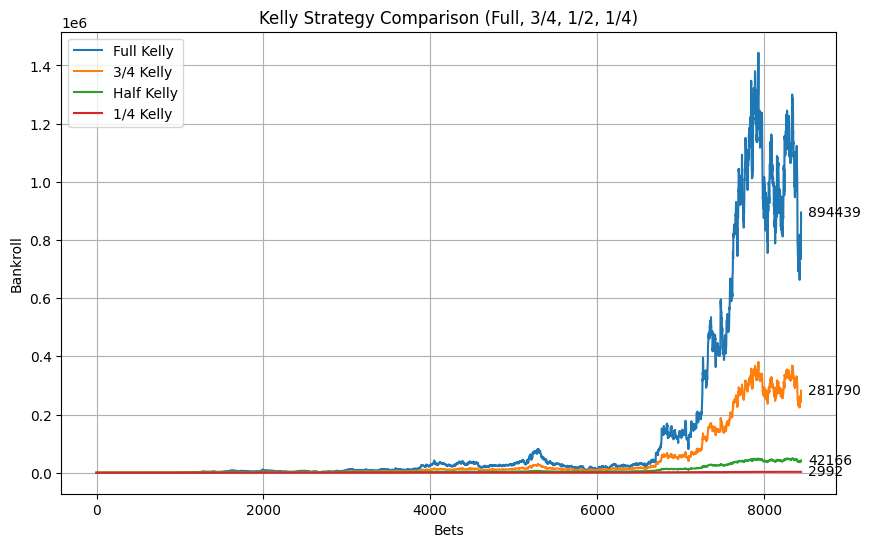

In [17]:
import matplotlib.pyplot as plt

# Plot the bankrolls
ax = main_df[['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']].plot(figsize=(10, 6))

# Set labels and title
plt.title('Kelly Strategy Comparison (Full, 3/4, 1/2, 1/4)')
plt.xlabel('Bets')
plt.ylabel('Bankroll')
plt.grid(True)

# Get the last index for annotation
last_index = main_df.index[-1]

# Annotate the last value for each line (rounded to whole number)
for column in ['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']:
    value = main_df.loc[last_index, column]
    ax.annotate(f'{value:.0f}', xy=(last_index, value), xytext=(5, 0),
                textcoords='offset points', va='center')

# Customize legend
plt.legend(['Full Kelly', '3/4 Kelly', 'Half Kelly', '1/4 Kelly'])

plt.show()

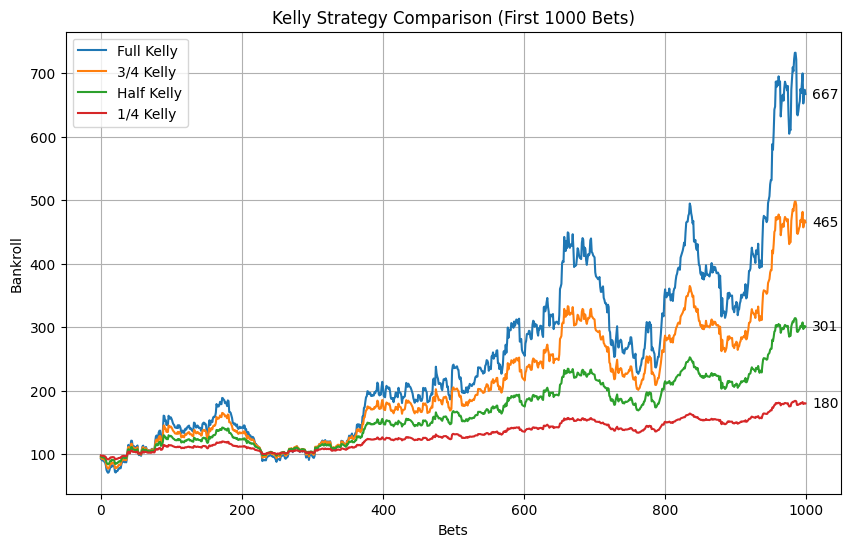

In [18]:
import matplotlib.pyplot as plt

# Slice the first 1000 rows
subset = main_df.iloc[:1000]

# Plot the bankrolls for first 1000 rows
ax = subset[['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']].plot(figsize=(10, 6))

# Set labels and title
plt.title('Kelly Strategy Comparison (First 1000 Bets)')
plt.xlabel('Bets')
plt.ylabel('Bankroll')
plt.grid(True)

# Annotate final value (at row 999)
last_index = subset.index[-1]
for column in ['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']:
    value = subset.loc[last_index, column]
    ax.annotate(f'{value:.0f}', xy=(last_index, value), xytext=(5, 0),
                textcoords='offset points', va='center')

# Add legend
plt.legend(['Full Kelly', '3/4 Kelly', 'Half Kelly', '1/4 Kelly'])

plt.show()

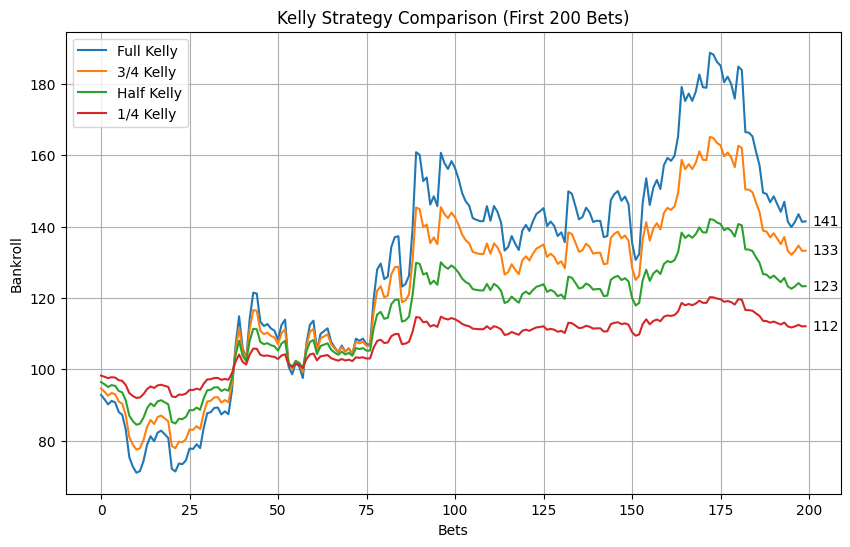

In [19]:
import matplotlib.pyplot as plt

# Create a copy of the first 200 rows
subset = main_df.iloc[:200].copy()

# Plot bankrolls
ax = subset[['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']].plot(figsize=(10, 6))

# Labels and title
plt.title('Kelly Strategy Comparison (First 200 Bets)')
plt.xlabel('Bets')
plt.ylabel('Bankroll')
plt.grid(True)

# Annotate final value at row 199
last_index = subset.index[-1]
for column in ['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']:
    value = subset.loc[last_index, column]
    ax.annotate(f'{value:.0f}', xy=(last_index, value), xytext=(5, 0),
                textcoords='offset points', va='center')

# Add legend
plt.legend(['Full Kelly', '3/4 Kelly', 'Half Kelly', '1/4 Kelly'])

plt.show()

In [20]:
%whos


Variable                        Type         Data/Info
------------------------------------------------------
away_col                        str          VCA
away_cols                       list         n=6
ax                              Axes         Axes(0.125,0.11;0.775x0.77)
bankroll_kelly_1                float64      911469.2360665648
bankroll_kelly_3qtr             float64      285872.5855230129
bankroll_kelly_half             float64      42579.11321966121
bankroll_kelly_qtr              float64      3006.8755490701988
betsize                         float64      16.079607946272567
book                            str          VC
bookmakers                      list         n=6
calculate_ev_from_odds          function     <function calculate_ev_fr<...>ds at 0x0000022D846728E0>
calculate_kelly_stake           function     <function calculate_kelly<...>ke at 0x0000022DE3557E20>
col_list                        list         n=12
column                          str          bankroll

In [21]:
main_df

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds,pinnacle_true_home_prob,pinnacle_true_draw_prob,pinnacle_true_away_prob,totes,home_ev,draw_ev,away_ev,max_value,betsize_kelly_1,bankroll_kelly_1,bet_on_kelly_1,betsize_kelly_3qtr,bankroll_kelly_3qtr,bet_on_kelly_3qtr,betsize_kelly_half,bankroll_kelly_half,bet_on_kelly_half,betsize_kelly_qtr,bankroll_kelly_qtr,bet_on_kelly_qtr
0,2,D1,2016-01-10,Ingolstadt,Hoffenheim,1.0,2.0,2.02,3.64,4.00,2.25,3.64,4.00,0.488458,0.268134,0.243408,1.0,0.099030,-0.023993,-0.026366,0.099030,7.985625,92.812121,H,5.977400,94.621434,H,3.977040,96.422531,H,1.984566,98.215394,H
1,3,D1,2016-01-10,Leverkusen,Dortmund,2.0,0.0,3.70,3.84,2.04,3.80,3.84,2.10,0.263309,0.253456,0.483235,1.0,0.000575,-0.026730,0.014794,0.014794,1.248209,91.563912,A,0.954407,93.667027,A,0.648383,95.774149,A,0.330219,97.885175,A
2,5,E1,2016-01-10,Fulham,QPR,1.0,2.0,2.03,3.42,4.17,2.10,3.50,4.17,0.484339,0.284125,0.231536,1.0,0.017111,-0.005561,-0.034495,0.017111,1.424327,90.139585,H,1.092781,92.574245,H,0.744910,95.029239,H,0.380664,97.504510,H
3,9,E1,2016-01-10,Leeds,Barnsley,2.0,1.0,2.12,3.45,3.79,2.20,3.50,3.79,0.463230,0.281387,0.255384,1.0,0.019105,-0.015147,-0.032096,0.019105,1.423642,91.127488,H,1.098776,93.337569,H,0.753454,95.553250,H,0.387316,97.774179,H
4,11,E1,2016-01-10,Reading,Derby,1.0,1.0,2.81,3.23,2.79,2.90,3.25,2.79,0.347908,0.301633,0.350459,1.0,0.008933,-0.019691,-0.022220,0.008933,0.428421,90.699067,H,0.329108,93.008461,H,0.224614,95.328636,H,0.114917,97.659261,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8439,62463,E3,2025-11-02,Barrow,Milton Keynes Dons,2.0,1.0,2.03,3.30,3.95,2.10,3.40,3.95,0.476342,0.286762,0.236896,1.0,0.000319,-0.025010,-0.064261,0.000319,216.801569,748368.519438,H,53.431972,245899.942760,H,5.568591,38437.857414,H,0.206755,2854.075428,H
8440,62562,SP1,2025-12-01,Ath Madrid,Osasuna,1.0,0.0,1.29,5.76,11.15,1.33,5.76,11.15,0.762363,0.160781,0.076856,1.0,0.013943,-0.073903,-0.143058,0.013943,30969.473860,743177.650914,H,7672.186240,244636.383046,H,803.701974,38307.816270,H,29.993221,2849.308323,H
8441,62580,I2,2025-12-01,Cosenza,Mantova,2.0,2.0,1.93,3.38,4.24,2.00,3.38,4.24,0.501521,0.279244,0.219235,1.0,0.003042,-0.056155,-0.070443,0.003042,2240.366132,734336.882297,H,554.343828,242451.800510,H,57.999406,38079.555026,H,2.161790,2840.811771,H
8442,62630,SP1,2025-12-04,Leganes,Barcelona,0.0,1.0,7.49,6.35,1.34,8.50,6.35,1.34,0.121091,0.145060,0.733849,1.0,0.029276,-0.078868,-0.016643,0.029276,3023.628766,771589.041738,H,739.041162,251704.051621,H,76.365489,39051.238841,H,2.810430,2877.165226,H


In [26]:
import pandas as pd
from IPython.display import display

# Define Kelly strategies and corresponding betsize columns
kelly_variants = {
    'bankroll_kelly_1': 'betsize_kelly_1',
    'bankroll_kelly_3qtr': 'betsize_kelly_3qtr',
    'bankroll_kelly_half': 'betsize_kelly_half',
    'bankroll_kelly_qtr': 'betsize_kelly_qtr'
}

# Build the table rows
table_data = []

for bankroll_col, betsize_col in kelly_variants.items():
    kelly_label = bankroll_col

    betsize_sum = main_df[betsize_col].sum()
    final_bankroll = main_df[bankroll_col].iloc[-1]
    winnings_net = final_bankroll - 100
    roi_percent = (winnings_net / betsize_sum) * 100 if betsize_sum != 0 else 0

    # Format numbers: thousands dot, decimal comma
    def format_number(n):
        return f"{int(round(n)):,}".replace(",", "X").replace(".", ",").replace("X", ".")

    def format_percent(p):
        return f"{p:.2f}".replace(".", ",") + " %"

    table_data.append([
        kelly_label,
        format_number(betsize_sum),
        format_number(winnings_net),
        format_percent(roi_percent)
    ])

# Create DataFrame
summary_df = pd.DataFrame(
    table_data,
    columns=["Kelly fraction", "Betsize sum", "Winnings net", "ROI %"]
)

# Display nicely in Jupyter
display(summary_df)




,Kelly fraction,Betsize sum,Winnings net,ROI %
0,bankroll_kelly_1,20.009.337,894.339,"4,47 %"
1,bankroll_kelly_3qtr,4.868.844,281.690,"5,79 %"
2,bankroll_kelly_half,585.480,42.066,"7,18 %"
3,bankroll_kelly_qtr,34.953,2.892,"8,27 %"


In [33]:
from tabulate import tabulate

# Define column alignments: left for label, center for numbers
alignment = ["left", "left", "right", "right", "right"]

print(tabulate(summary_df, headers='keys', tablefmt='fancy_grid', colalign=alignment))



╒════╤═════════════════════╤═══════════════╤════════════════╤═════════╕
│    │ Kelly fraction      │   Betsize sum │   Winnings net │   ROI % │
╞════╪═════════════════════╪═══════════════╪════════════════╪═════════╡
│ 0  │ bankroll_kelly_1    │    20.009.337 │        894.339 │  4,47 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 1  │ bankroll_kelly_3qtr │     4.868.844 │         281.69 │  5,79 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 2  │ bankroll_kelly_half │       585.480 │         42.066 │  7,18 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 3  │ bankroll_kelly_qtr  │        34.953 │          2.892 │  8,27 % │
╘════╧═════════════════════╧═══════════════╧════════════════╧═════════╛


In [29]:
import pandas as pd
from IPython.display import display

# Slice the first 1000 rows
df_subset = main_df.head(1000)

# Define Kelly strategies and corresponding betsize columns
kelly_variants = {
    'bankroll_kelly_1': 'betsize_kelly_1',
    'bankroll_kelly_3qtr': 'betsize_kelly_3qtr',
    'bankroll_kelly_half': 'betsize_kelly_half',
    'bankroll_kelly_qtr': 'betsize_kelly_qtr'
}

# Build the table rows
table_data = []

for bankroll_col, betsize_col in kelly_variants.items():
    kelly_label = bankroll_col

    betsize_sum = df_subset[betsize_col].sum()
    final_bankroll = df_subset[bankroll_col].iloc[-1]
    winnings_net = final_bankroll - 100
    roi_percent = (winnings_net / betsize_sum) * 100 if betsize_sum != 0 else 0

    # Format numbers: thousands dot, decimal comma
    def format_number(n):
        return f"{int(round(n)):,}".replace(",", "X").replace(".", ",").replace("X", ".")

    def format_percent(p):
        return f"{p:.2f}".replace(".", ",") + " %"

    table_data.append([
        kelly_label,
        format_number(betsize_sum),
        format_number(winnings_net),
        format_percent(roi_percent)
    ])

# Create DataFrame
summary_df_1000 = pd.DataFrame(
    table_data,
    columns=["Kelly fraction", "Betsize sum", "Winnings net", "ROI %"]
)

# Display nicely in Jupyter
display(summary_df_1000)


,Kelly fraction,Betsize sum,Winnings net,ROI %
0,bankroll_kelly_1,5.192,567,"10,93 %"
1,bankroll_kelly_3qtr,3.245,365,"11,26 %"
2,bankroll_kelly_half,1.744,201,"11,51 %"
3,bankroll_kelly_qtr,686,80,"11,69 %"


In [34]:
from tabulate import tabulate

# Define column alignments: left for label, center for numbers
alignment = ["left", "left", "right", "right", "right"]

print(tabulate(summary_df_1000, headers='keys', tablefmt='fancy_grid', colalign=alignment))

╒════╤═════════════════════╤═══════════════╤════════════════╤═════════╕
│    │ Kelly fraction      │   Betsize sum │   Winnings net │   ROI % │
╞════╪═════════════════════╪═══════════════╪════════════════╪═════════╡
│ 0  │ bankroll_kelly_1    │         5.192 │            567 │ 10,93 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 1  │ bankroll_kelly_3qtr │         3.245 │            365 │ 11,26 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 2  │ bankroll_kelly_half │         1.744 │            201 │ 11,51 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 3  │ bankroll_kelly_qtr  │           686 │             80 │ 11,69 % │
╘════╧═════════════════════╧═══════════════╧════════════════╧═════════╛


In [30]:
import pandas as pd
from IPython.display import display

# Slice the first 200 rows
df_subset = main_df.head(200)

# Define Kelly strategies and corresponding betsize columns
kelly_variants = {
    'bankroll_kelly_1': 'betsize_kelly_1',
    'bankroll_kelly_3qtr': 'betsize_kelly_3qtr',
    'bankroll_kelly_half': 'betsize_kelly_half',
    'bankroll_kelly_qtr': 'betsize_kelly_qtr'
}

# Build the table rows
table_data = []

for bankroll_col, betsize_col in kelly_variants.items():
    kelly_label = bankroll_col

    betsize_sum = df_subset[betsize_col].sum()
    final_bankroll = df_subset[bankroll_col].iloc[-1]
    winnings_net = final_bankroll - 100
    roi_percent = (winnings_net / betsize_sum) * 100 if betsize_sum != 0 else 0

    # Format numbers: thousands dot, decimal comma
    def format_number(n):
        return f"{int(round(n)):,}".replace(",", "X").replace(".", ",").replace("X", ".")

    def format_percent(p):
        return f"{p:.2f}".replace(".", ",") + " %"

    table_data.append([
        kelly_label,
        format_number(betsize_sum),
        format_number(winnings_net),
        format_percent(roi_percent)
    ])

# Create DataFrame
summary_df_200 = pd.DataFrame(
    table_data,
    columns=["Kelly fraction", "Betsize sum", "Winnings net", "ROI %"]
)

# Display nicely in Jupyter
display(summary_df_200)


,Kelly fraction,Betsize sum,Winnings net,ROI %
0,bankroll_kelly_1,556,41,"7,46 %"
1,bankroll_kelly_3qtr,399,33,"8,34 %"
2,bankroll_kelly_half,253,23,"9,22 %"
3,bankroll_kelly_qtr,119,12,"10,12 %"


In [35]:
from tabulate import tabulate

# Define column alignments: left for label, center for numbers
alignment = ["left", "left", "right", "right", "right"]

print(tabulate(summary_df_200, headers='keys', tablefmt='fancy_grid', colalign=alignment))

╒════╤═════════════════════╤═══════════════╤════════════════╤═════════╕
│    │ Kelly fraction      │   Betsize sum │   Winnings net │   ROI % │
╞════╪═════════════════════╪═══════════════╪════════════════╪═════════╡
│ 0  │ bankroll_kelly_1    │           556 │             41 │  7,46 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 1  │ bankroll_kelly_3qtr │           399 │             33 │  8,34 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 2  │ bankroll_kelly_half │           253 │             23 │  9,22 % │
├────┼─────────────────────┼───────────────┼────────────────┼─────────┤
│ 3  │ bankroll_kelly_qtr  │           119 │             12 │ 10,12 % │
╘════╧═════════════════════╧═══════════════╧════════════════╧═════════╛
